<a href="https://colab.research.google.com/github/NIVYASHREE847/test_model_rock_yolov8m/blob/main/testingmodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
torch.cuda.is_available()

True

In [2]:
!nvidia-smi

Mon Mar 16 13:37:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import torch
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [5]:
!pip install ultralytics roboflow

In [6]:
import os
from roboflow import Roboflow
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import Image, display

In [7]:
rf = Roboflow(api_key="iKiMoJB2fenhaxOvzKlB")
project = rf.workspace("nasarockyard").project("nasa-rockyard")
dataset = project.version(6).download("yolov8")

print("Dataset downloaded to:", dataset.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to NASA-Rockyard-6 in yolov8:: 100%|██████████| 2166/2166 [00:00<00:00, 2575.93it/s]

Dataset downloaded to: /content/NASA-Rockyard-6


In [8]:
import os

dataset_path = dataset.location

for split in ["train", "valid", "test"]:
    img_path = os.path.join(dataset_path, split, "images")
    if os.path.exists(img_path):
        count = len(os.listdir(img_path))
        print(f"{split}: {count} images")


yaml_path = os.path.join(dataset_path, "data.yaml")
print("\ndata.yaml path:", yaml_path)

with open(yaml_path, "r") as f:
    print(f.read())

train: 989 images
valid: 47 images
test: 41 images

data.yaml path: /content/NASA-Rockyard-6/data.yaml
names:
- rock
nc: 1
roboflow:
  license: CC BY 4.0
  project: nasa-rockyard
  url: https://universe.roboflow.com/nasarockyard/nasa-rockyard/dataset/6
  version: 6
  workspace: nasarockyard
test: ../test/images
train: ../train/images
val: ../valid/images



In [9]:
model = YOLO("yolov8m.pt")  # Auto-downloads yolo11m weights
print("YOLOv11m loaded successfully!")

YOLOv11m loaded successfully!


In [10]:
results = model.train(
    data=yaml_path,         # Path to data.yaml
    epochs=100,              # Increase to 100 for better accuracy
    imgsz=640,              # Image size
    batch=16,               # Reduce to 8 if you get OOM errors
    name="rock_detector",   # Run name (saved in runs/detect/)
    patience=20,            # Early stopping
    device=0                # Use GPU (0); set to 'cpu' if no GPU
)

print("Training complete!")

Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/NASA-Rockyard-6/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=rock_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, p

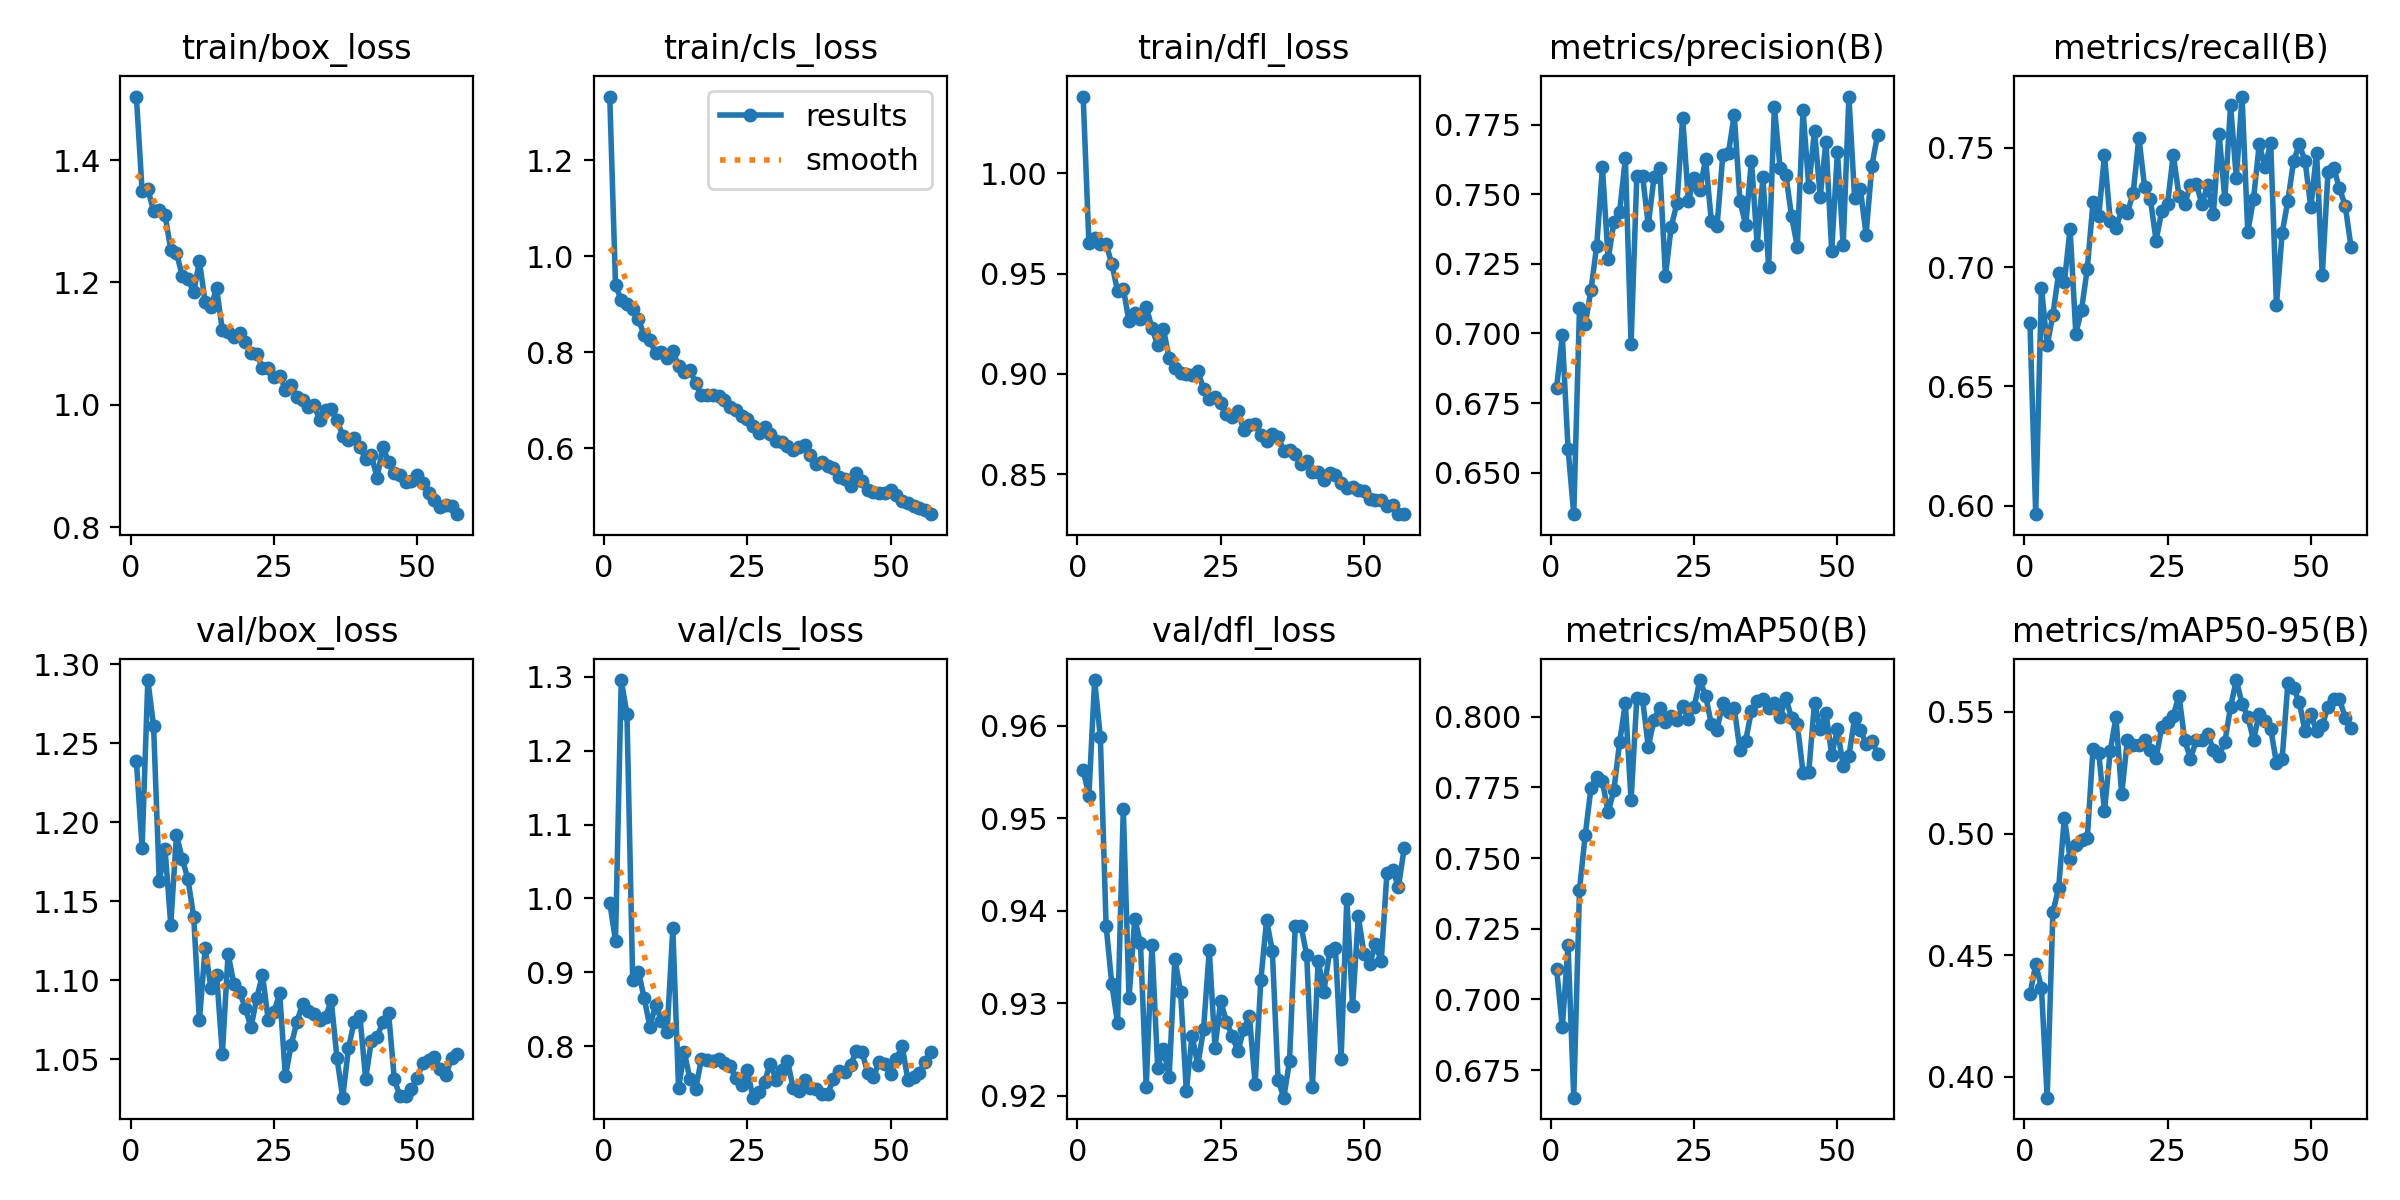

In [11]:
# Plot training curves
metrics_img = "runs/detect/rock_detector/results.png"
display(Image(filename=metrics_img))

In [12]:
metrics = model.val()

print(f"mAP50:     {metrics.box.map50:.4f}")
print(f"mAP50-95:  {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.p.mean():.4f}")
print(f"Recall:    {metrics.box.r.mean():.4f}")

Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1767.5±938.4 MB/s, size: 67.4 KB)
val: Scanning /content/NASA-Rockyard-6/valid/labels.cache... 47 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 47/47 24.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.3it/s 2.3s
                   all         47       1400      0.757      0.737      0.807      0.567
Speed: 6.1ms preprocess, 20.0ms inference, 0.0ms loss, 4.1ms postprocess per image
Results saved to /content/runs/detect/val
mAP50:     0.8067
mAP50-95:  0.5667
Precision: 0.7573
Recall:    0.7371


In [13]:
test_img_dir = os.path.join(dataset_path, "test", "images")
test_images = [
    os.path.join(test_img_dir, f)
    for f in os.listdir(test_img_dir)
    if f.endswith((".jpg", ".jpeg", ".png"))
][:5]  # Take first 5 test images

results = model.predict(
    source=test_images,
    conf=0.25,          # Confidence threshold
    iou=0.45,           # NMS IoU threshold
    save=True,          # Save annotated images
    name="rock_preds4"
)

print(f"Predictions saved to: runs/detect/rock_preds4/")


0: 384x640 48 rocks, 20.0ms
1: 384x640 15 rocks, 20.0ms
2: 384x640 34 rocks, 20.0ms
3: 384x640 75 rocks, 20.0ms
4: 384x640 93 rocks, 20.0ms
Speed: 1.8ms preprocess, 20.0ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/rock_preds4
Predictions saved to: runs/detect/rock_preds4/


In [14]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


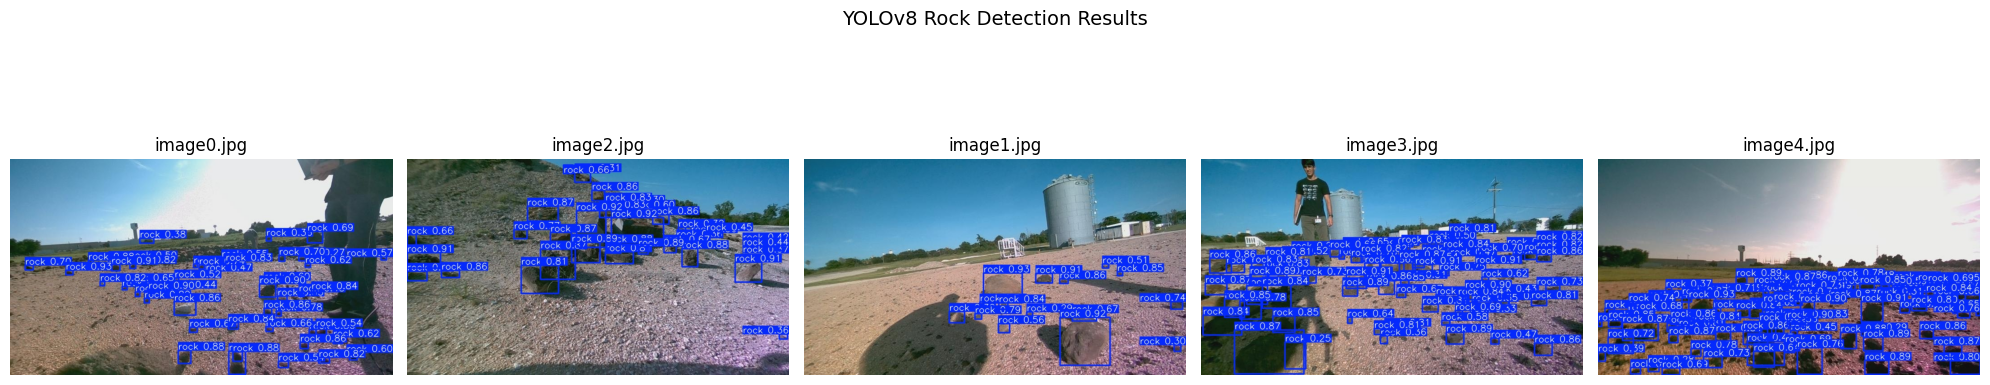

In [15]:
pred_dir = "runs/detect/rock_preds4/"
pred_images = [
    os.path.join(pred_dir, f)
    for f in os.listdir(pred_dir)
    if f.endswith((".jpg", ".png"))
][:5]

fig, axes = plt.subplots(1, len(pred_images), figsize=(20, 5))

for ax, img_path in zip(axes, pred_images):
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(os.path.basename(img_path))

plt.suptitle("YOLOv8 Rock Detection Results", fontsize=14)
plt.tight_layout()
plt.show()

In [16]:
import shutil

best_model_src = "runs/detect/rock_detector/weights/best.pt"
best_model_dst = "rock_detector_best4.pt"

shutil.copy(best_model_src, best_model_dst)
print(f"Best model saved to: {best_model_dst}")

Best model saved to: rock_detector_best4.pt


In [18]:
# Replace with any rock image path or URL
custom_image = "/testrock.jpg"

result = model.predict(
    source=custom_image,
    conf=0.25,
    save=True,
    name="custom_test"
)

for r in result:
    print(f"Detected {len(r.boxes)} rock(s)")
    for box in r.boxes:
        print(f"  Class: {r.names[int(box.cls)]}, Confidence: {box.conf.item():.2f}, BBox: {box.xyxy.tolist()}")


image 1/1 /testrock.jpg: 448x640 14 rocks, 46.5ms
Speed: 2.4ms preprocess, 46.5ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/custom_test
Detected 14 rock(s)
  Class: rock, Confidence: 0.90, BBox: [[147.50308227539062, 270.90234375, 287.38250732421875, 368.59228515625]]
  Class: rock, Confidence: 0.87, BBox: [[283.10443115234375, 278.93896484375, 373.7558288574219, 352.0708923339844]]
  Class: rock, Confidence: 0.82, BBox: [[201.17420959472656, 346.0493469238281, 338.04608154296875, 463.5871276855469]]
  Class: rock, Confidence: 0.82, BBox: [[376.2583923339844, 338.80853271484375, 477.7794189453125, 414.4876403808594]]
  Class: rock, Confidence: 0.72, BBox: [[478.5392150878906, 353.5637512207031, 594.5733642578125, 445.80615234375]]
  Class: rock, Confidence: 0.70, BBox: [[238.84783935546875, 565.905029296875, 264.73162841796875, 592.6846313476562]]
  Class: rock, Confidence: 0.57, BBox: [[434.80474853515625, 71.71434020996094


image 1/1 /testrock.jpg: 448x640 14 rocks, 27.7ms
Speed: 2.0ms preprocess, 27.7ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)
Detected 14 rock(s)


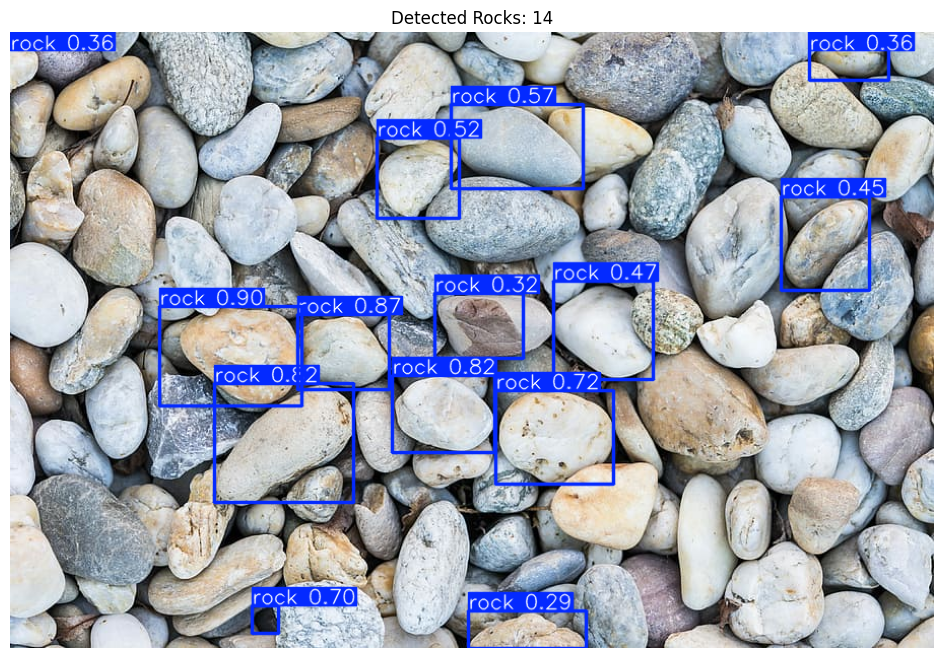

In [20]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Load trained model
model = YOLO("rock_detector_best4.pt")   # change if your model name is different

# Image path
custom_image = "/testrock.jpg"

# Run prediction
results = model.predict(
    source=custom_image,
    conf=0.25,
    save=False
)

# Get annotated image with boxes
annotated_frame = results[0].plot()

# Count detected rocks
rock_count = len(results[0].boxes)

print(f"Detected {rock_count} rock(s)")

# Display image inside Jupyter
plt.figure(figsize=(12,8))
plt.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
plt.title(f"Detected Rocks: {rock_count}")
plt.axis("off")
plt.show()

In [21]:
!find /content -name rock_detector_best4.pt -print

/content/rock_detector_best4.pt



0: 384x640 48 rocks, 13.0ms
1: 384x640 15 rocks, 13.0ms
2: 384x640 34 rocks, 13.0ms
3: 384x640 75 rocks, 13.0ms
4: 384x640 93 rocks, 13.0ms
5: 384x640 25 rocks, 13.0ms
6: 384x640 18 rocks, 13.0ms
7: 384x640 46 rocks, 13.0ms
8: 384x640 44 rocks, 13.0ms
9: 384x640 10 rocks, 13.0ms
10: 384x640 20 rocks, 13.0ms
11: 384x640 38 rocks, 13.0ms
12: 384x640 24 rocks, 13.0ms
13: 384x640 83 rocks, 13.0ms
14: 384x640 46 rocks, 13.0ms
15: 384x640 69 rocks, 13.0ms
16: 384x640 38 rocks, 13.0ms
17: 384x640 37 rocks, 13.0ms
18: 384x640 55 rocks, 13.0ms
19: 384x640 19 rocks, 13.0ms
20: 384x640 3 rocks, 13.0ms
21: 384x640 55 rocks, 13.0ms
22: 384x640 64 rocks, 13.0ms
23: 384x640 76 rocks, 13.0ms
24: 384x640 21 rocks, 13.0ms
25: 384x640 89 rocks, 13.0ms
26: 384x640 46 rocks, 13.0ms
27: 384x640 8 rocks, 13.0ms
28: 384x640 33 rocks, 13.0ms
29: 384x640 40 rocks, 13.0ms
30: 384x640 19 rocks, 13.0ms
31: 384x640 31 rocks, 13.0ms
32: 384x640 95 rocks, 13.0ms
33: 384x640 44 rocks, 13.0ms
34: 384x640 21 rocks, 13.

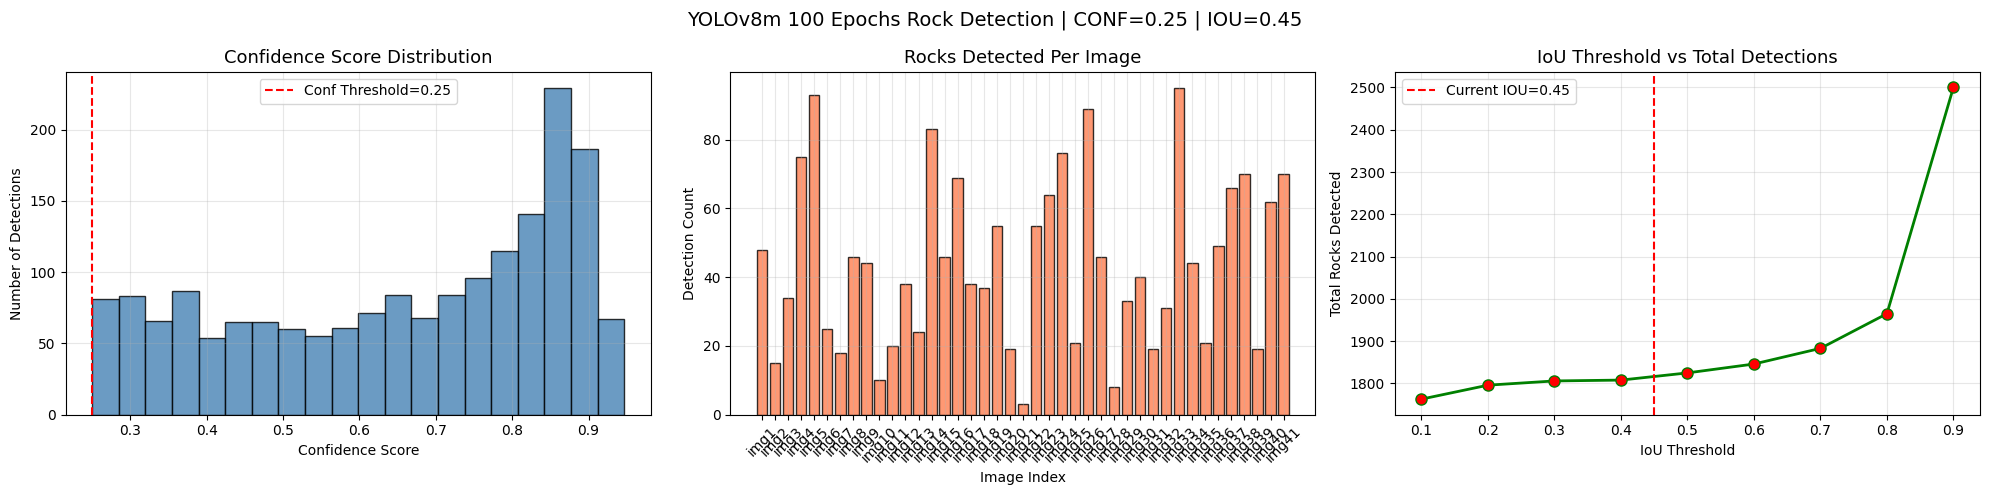


Total images     : 41
Total detections : 1818
Avg per image    : 44.3
Max detections   : 95
Min detections   : 3
Avg confidence   : 0.654


In [22]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

# ========== CONFIGURE HERE ==========
MODEL_PATH   = r"rock_detector_best4.pt"
TEST_IMG_DIR = r"/content/NASA-Rockyard-6/test/images"
CONF         = 0.25
IOU          = 0.45
# =====================================

# Load model
model = YOLO(MODEL_PATH)

# Collect test images
test_images = [
    os.path.join(TEST_IMG_DIR, f)
    for f in os.listdir(TEST_IMG_DIR)
    if f.endswith((".jpg", ".jpeg", ".png"))
]

# Predict
results = model.predict(
    source=test_images,
    conf=CONF,
    iou=IOU,
    save=False
)

# ---- Collect confidence scores per image ----
all_confs   = []
image_names = []
image_counts = []

for i, r in enumerate(results):
    img_name = os.path.basename(test_images[i])
    confs = r.boxes.conf.cpu().numpy() if len(r.boxes) > 0 else np.array([])
    all_confs.append(confs)
    image_names.append(img_name)
    image_counts.append(len(confs))

# ---- Plot 1: Confidence score distribution (acts as IoU proxy) ----
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Graph 1 — Confidence Distribution across all detections
all_scores = np.concatenate(all_confs) if all_confs else np.array([])
axes[0].hist(all_scores, bins=20, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(CONF, color='red', linestyle='--', label=f'Conf Threshold={CONF}')
axes[0].set_title("Confidence Score Distribution", fontsize=13)
axes[0].set_xlabel("Confidence Score")
axes[0].set_ylabel("Number of Detections")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Graph 2 — Per image detection count
axes[1].bar(range(len(image_counts)), image_counts, color='coral', edgecolor='black', alpha=0.8)
axes[1].set_title("Rocks Detected Per Image", fontsize=13)
axes[1].set_xlabel("Image Index")
axes[1].set_ylabel("Detection Count")
axes[1].set_xticks(range(len(image_names)))
axes[1].set_xticklabels([f"img{i+1}" for i in range(len(image_names))], rotation=45)
axes[1].grid(True, alpha=0.3)

# Graph 3 — IoU threshold vs Detection count
iou_thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
detection_counts = []

for iou_val in iou_thresholds:
    res = model.predict(source=test_images, conf=CONF, iou=iou_val, verbose=False)
    total = sum(len(r.boxes) for r in res)
    detection_counts.append(total)

axes[2].plot(iou_thresholds, detection_counts, marker='o', color='green',
             linewidth=2, markersize=8, markerfacecolor='red')
axes[2].axvline(IOU, color='red', linestyle='--', label=f'Current IOU={IOU}')
axes[2].set_title("IoU Threshold vs Total Detections", fontsize=13)
axes[2].set_xlabel("IoU Threshold")
axes[2].set_ylabel("Total Rocks Detected")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle(f"YOLOv8m 100 Epochs Rock Detection | CONF={CONF} | IOU={IOU}", fontsize=14)
plt.tight_layout()
plt.show()

# Summary
print(f"\nTotal images     : {len(test_images)}")
print(f"Total detections : {int(all_scores.shape[0])}")
print(f"Avg per image    : {np.mean(image_counts):.1f}")
print(f"Max detections   : {max(image_counts)}")
print(f"Min detections   : {min(image_counts)}")
print(f"Avg confidence   : {np.mean(all_scores):.3f}")

In [23]:
!zip rock_model.zip /content/runs/detect/train/weights/best.pt

	zip warning: name not matched: /content/runs/detect/train/weights/best.pt

zip error: Nothing to do! (rock_model.zip)


In [24]:
!zip rock_model.zip rock_detector_best4.pt

  adding: rock_detector_best4.pt (deflated 8%)


In [25]:
from google.colab import files
files.download("/content/rock_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
!ls -lh

total 151M
drwx------ 5 root root 4.0K Mar 16 14:14 drive
drwxr-xr-x 5 root root 4.0K Mar 16 13:37 NASA-Rockyard-6
-rw-r--r-- 1 root root  50M Mar 16 14:14 rock_detector_best4.pt
-rw-r--r-- 1 root root  46M Mar 16 14:24 rock_model.zip
drwxr-xr-x 3 root root 4.0K Mar 16 13:37 runs
drwxr-xr-x 1 root root 4.0K Feb  6 14:31 sample_data
-rw-r--r-- 1 root root 5.3M Mar 16 13:37 yolo26n.pt
-rw-r--r-- 1 root root  50M Mar 16 13:37 yolov8m.pt


In [27]:
!ls -lh /content/runs/detect/rock_detector/weights

total 100M
-rw-r--r-- 1 root root 50M Mar 16 14:13 best.pt
-rw-r--r-- 1 root root 50M Mar 16 14:13 last.pt


In [28]:
from google.colab import files
files.download("rock_detector_best4.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
from google.colab import drive
drive.mount('/content/drive')

!cp rock_detector_best4.pt /content/drive/MyDrive/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
from google.colab import drive
drive.mount('/content/drive')

!cp rock_detector_best4.pt /content/drive/MyDrive/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
